# EMG Gesture Recognition - Model Pipeline
**PSCD Group 8 - Amir Forooharfar**

This notebook loads real 2-channel EMG data, slices it into fixed-length windows, and trains a 1D Convolutional Neural Network to classify 3 hand gestures: **Rest**, **Fist**, and **Wrist extension**.

**Dataset:** UCI EMG data for gestures: https://archive.ics.uci.edu/dataset/481/emg+data+for+gestures  
Download the ZIP, extract it into a folder called `emg_data/` next to this notebook.

---
## 1. Install and import libraries

In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow --quiet


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\amirf\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


---
## 2. Configuration

All settings in one place. Change them here and re-run the notebook to experiment.

In [3]:
DATA_DIR    = 'emg_data'   # folder where I extracted the dataset
FS          = 500          # sampling rate in Hz (same as our firmware)
WINDOW_MS   = 600          # how long each input window is, in milliseconds
WINDOW_SAMP = int(FS * WINDOW_MS / 1000)  # = 300 samples per window
STEP_SAMP   = 50          # sliding window step — how much we move forward each time
                           # smaller step = more overlap = more training windows

# The dataset uses these class numbers:
# 0 = unlabelled / transition  - we skip this one
# 1 = hand at rest
# 2 = fist
# 4 = wrist extension

# I pick 3 gestures 
GESTURE_IDS = [1, 2, 4]
GESTURE_NAMES = {
    1: 'Rest',
    2: 'Fist',
    4: 'Wrist extension',
}

# Which 2 of the 8 channels to use
# Wearable-friendly pair: one flexor-side + one extensor-side channel
CHANNELS = [0, 4]

# MODEL ARCHITECTURE HYPERPARAMETERS
CONV_FILTERS_1 = 16          # first Conv1D layer
CONV_KERNEL_1  = 15
CONV_FILTERS_2 = 32          # second Conv1D layer
CONV_KERNEL_2  = 7
DENSE_UNITS    = 32
DROPOUT_RATE   = 0.45


# TRAINING HYPERPARAMETERS
LEARNING_RATE  = 0.0005      # Adam optimizer learning rate
BATCH_SIZE     = 32
EPOCHS         = 40          # practical upper bound; early stopping will stop sooner
EARLY_STOP_PATIENCE = 8      # stop if val_accuracy doesn't improve for N epochs

print(f'Window: {WINDOW_SAMP} samples = {WINDOW_MS} ms at {FS} Hz')
print(f'Gestures: {GESTURE_NAMES}')
print(f'Channels used: {CHANNELS}')
print(f'\nModel: Conv({CONV_FILTERS_1},{CONV_KERNEL_1}) -> Conv({CONV_FILTERS_2},{CONV_KERNEL_2}) -> Dense({DENSE_UNITS}) -> Dropout({DROPOUT_RATE})')
print(f'Training: {EPOCHS} epochs, batch_size={BATCH_SIZE}, learning_rate={LEARNING_RATE}, early_stop_patience={EARLY_STOP_PATIENCE}')

Window: 300 samples = 600 ms at 500 Hz
Gestures: {1: 'Rest', 2: 'Fist', 4: 'Wrist extension'}
Channels used: [0, 4]

Model: Conv(16,15) -> Conv(32,7) -> Dense(32) -> Dropout(0.45)
Training: 40 epochs, batch_size=32, learning_rate=0.0005, early_stop_patience=8


---
## 3. Load the dataset

The dataset contains one `.txt` file per recording session. Each row is one time sample with 8 EMG channel values and a gesture label. We load all files and stack them into one big table.

In [4]:
all_frames = []

# Walk through the data folder looking for txt files 
for root, dirs, files in os.walk(DATA_DIR):
    for fname in sorted(files):
        # Look for .txt files (raw_data files in the UCI dataset)
        if not fname.endswith('.txt') or 'raw_data' not in fname:
            continue
        fpath = os.path.join(root, fname)
        try:
            # Skip the first row (header) and read as tab-separated values
            df = pd.read_csv(fpath, skiprows=1, header=None, sep='\t')
            all_frames.append(df)
        except Exception as e:
            print(f'Could not read {fpath}: {e}')

if len(all_frames) == 0:
    print('No TXT files found. Make sure emg_data/ exists with the extracted UCI dataset.')
else:
    raw = pd.concat(all_frames, ignore_index=True)
    # Rename columns: first column = time, last = label, middle = EMG channels
    n_cols = raw.shape[1]
    n_emg  = n_cols - 2  # subtract time and label columns
    raw.columns = ['time'] + [f'ch{i}' for i in range(n_emg)] + ['label']
    
    # Remove rows with any NaN values (empty rows at end of files)
    raw = raw.dropna()
    
    # Convert label to int — handle any remaining edge cases
    raw['label'] = pd.to_numeric(raw['label'], errors='coerce').fillna(0).astype(int)
    print(f'Loaded {len(all_frames)} TXT files')
    print(f'Total rows: {len(raw):,}  ({len(raw)/FS:.1f} seconds of data)')
    print(f'Columns: {list(raw.columns)}')
    print()
    print('Samples per gesture label:')
    print(raw['label'].value_counts().sort_index())


Loaded 72 TXT files
Total rows: 4,237,907  (8475.8 seconds of data)
Columns: ['time', 'ch0', 'ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'label']

Samples per gesture label:
label
0    2725157
1     250055
2     243193
3     249494
4     251570
5     251733
6     253009
7      13696
Name: count, dtype: int64


---
## 4. Look at the raw signal

Always plot the data before doing anything with it. There should be clear differences between gestures; especially between Fist (high flexor activity) and Wrist extension (high extensor activity). Rest should be quiet on both channels.

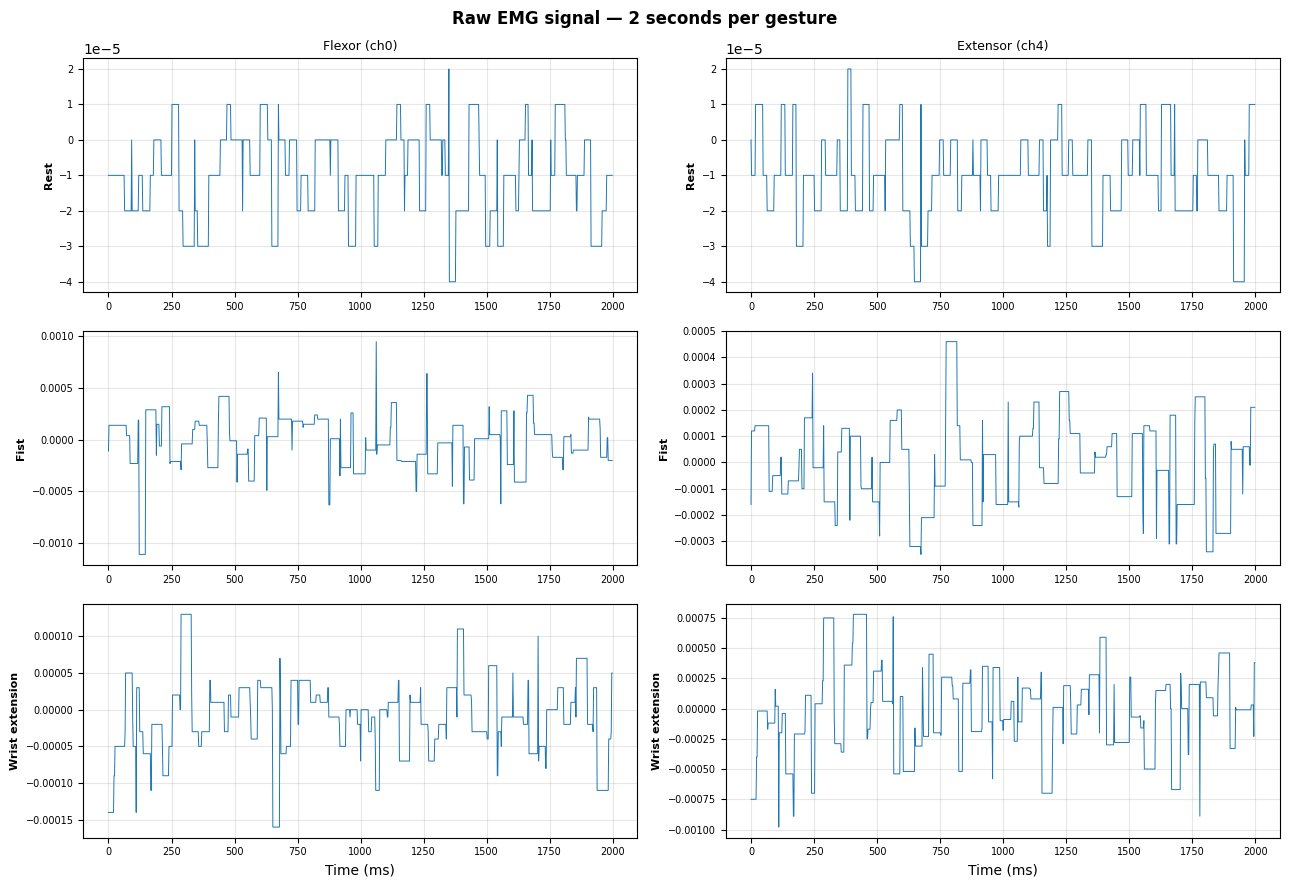

In [5]:
# Plot 2 seconds of raw signal for each gesture, both channels
plot_samples = FS * 2   # 2 seconds worth of samples
t = np.arange(plot_samples) / FS * 1000  # time in ms

ch_cols = [f'ch{c}' for c in CHANNELS]

fig, axes = plt.subplots(len(GESTURE_IDS), 2, figsize=(13, 9), sharey=False)
fig.suptitle('Raw EMG signal — 2 seconds per gesture', fontsize=12, fontweight='bold')

for row, gid in enumerate(GESTURE_IDS):
    # Find a continuous segment of this gesture
    segment = raw[raw['label'] == gid][ch_cols].values
    if len(segment) < plot_samples:
        print(f'Not enough samples for gesture {gid}')
        continue
    segment = segment[:plot_samples]

    channel_titles = ['Flexor (ch0)', 'Extensor (ch4)']
    for col, (ch_col, ch_label) in enumerate(zip(ch_cols, channel_titles)):
        ax = axes[row, col]
        ax.plot(t, segment[:, col], linewidth=0.7)
        ax.set_ylabel(GESTURE_NAMES[gid], fontsize=8, fontweight='bold')
        if row == 0:
            ax.set_title(ch_label, fontsize=9)
        if row == len(GESTURE_IDS) - 1:
            ax.set_xlabel('Time (ms)')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

---
## 5. Slice into windows

A neural network needs fixed-size inputs. We slide a window across the signal and collect one labelled example per window position. We skip any window that spans a gesture transition.

In [6]:
def make_windows(dataframe, gesture_ids, channels, window_samp, step_samp):
    """
    Slide a window across the signal and collect (window, label) pairs.
    We only keep windows where the label is the same for all samples inside
    (no gesture transitions mid-window).
    """
    ch_cols = [f'ch{c}' for c in channels]
    emg    = dataframe[ch_cols].values.astype(np.float32)
    labels = dataframe['label'].values

    X, y = [], []
    n = len(emg)

    for start in range(0, n - window_samp, step_samp):
        end    = start + window_samp
        window = emg[start:end]          # shape: (window_samp, n_channels)
        window_labels = labels[start:end]

        # Check that the entire window belongs to one gesture
        if len(set(window_labels)) != 1:
            continue   # skip transition windows

        gesture_id = window_labels[0]
        if gesture_id not in gesture_ids:
            continue   # skip gestures we don't want

        # Re-map gesture ID to a class index 0, 1, 2, 3 ...
        class_idx = gesture_ids.index(gesture_id)
        X.append(window)
        y.append(class_idx)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X, y = make_windows(raw, GESTURE_IDS, CHANNELS, WINDOW_SAMP, STEP_SAMP)

print(f'X shape: {X.shape}   → (number of windows, samples per window, channels)')
print(f'y shape: {y.shape}')
print()
for i, gid in enumerate(GESTURE_IDS):
    count = np.sum(y == i)
    print(f'  Class {i} — {GESTURE_NAMES[gid]}: {count} windows')

X shape: (12313, 300, 2)   → (number of windows, samples per window, channels)
y shape: (12313,)

  Class 0 — Rest: 4144 windows
  Class 1 — Fist: 4000 windows
  Class 2 — Wrist extension: 4169 windows


---
## 6. Normalise

Raw EMG amplitude varies between subjects and sessions depending on electrode contact, skin condition, etc. I subtract the mean and divide by the standard deviation and computed across the whole dataset per channel so the model sees consistent signal scale regardless of those variations.

In [7]:
# Global per-channel normalisation across the dataset
# preserves window-to-window amplitude differences useful for Fist vs Rest
mean = X.mean(axis=(0, 1), keepdims=True)   # shape: (1, 1, n_channels)
std  = X.std(axis=(0, 1), keepdims=True) + 1e-8
X_norm = (X - mean) / std

print(f'Before normalisation — mean: {X.mean():.4f}, std: {X.std():.4f}')
print(f'After  normalisation — mean: {X_norm.mean():.4f}, std: {X_norm.std():.4f}')

Before normalisation — mean: -0.0000, std: 0.0003
After  normalisation — mean: -0.0002, std: 1.0024


---
## 7. Train / validation / test split

- **Train (68%)** — what the model learns from  
- **Validation (17%)** — checked after each epoch to catch overfitting  
- **Test (15%)** — held out completely, only used for the final accuracy number

In [8]:
# First split off 15% as a test set — this is set aside and never touched during training
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_norm, y, test_size=0.15, stratify=y, random_state=42
)

# Then split the rest into 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42
)

N_CLASSES = len(GESTURE_IDS)

# Convert labels to one-hot (e.g. class 2 → [0, 0, 1, 0])
y_train_oh = tf.keras.utils.to_categorical(y_train, N_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   N_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  N_CLASSES)

print(f'Training:   {X_train.shape[0]} windows')
print(f'Validation: {X_val.shape[0]} windows')
print(f'Test:       {X_test.shape[0]} windows')
print(f'Input shape per window: {X_train.shape[1:]}')

Training:   8372 windows
Validation: 2094 windows
Test:       1847 windows
Input shape per window: (300, 2)


---
## 8. Model - 1D CNN

EMG is a time-series signal, so we use a **1D Convolutional Neural Network**. A Conv1D filter slides along the time axis and learns to detect local patterns like a muscle burst. This is better than a Dense (fully connected) network which would flatten the signal and lose all temporal structure.

```
Input  (300 samples × 2 channels)
  -> Conv1D(16 filters, size 15)  ->  MaxPooling
  -> Conv1D(32 filters, size 7)   ->  GlobalAveragePooling
  -> Dense(32)  ->  Dropout(0.45)
  -> Dense(3, softmax)    (one output per gesture)
```

GlobalAveragePooling collapses the time axis into a single fixed-size vector, which keeps the parameter count small which is important for eventual deployment on a microcontroller.

In [9]:
input_shape = (WINDOW_SAMP, len(CHANNELS))

model = keras.Sequential([
    keras.Input(shape=input_shape),

    # First conv block
    layers.Conv1D(filters=CONV_FILTERS_1, kernel_size=CONV_KERNEL_1, padding='same', activation='relu'),
    layers.MaxPooling1D(pool_size=2),

    # Second conv block
    layers.Conv1D(filters=CONV_FILTERS_2, kernel_size=CONV_KERNEL_2, padding='same', activation='relu'),
    layers.GlobalAveragePooling1D(),

    # Classifier
    layers.Dense(DENSE_UNITS, activation='relu'),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='emg_gesture_cnn')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "emg_gesture_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 300, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 32)        │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,267 (20.57 KB)

 Trainable params: 5,267 (20.57 KB)

 Non-trainable params: 0 (0.00 B)

---
## 9. Train

`EarlyStopping` monitors validation accuracy and stops training if it hasn't improved for 8 epochs, then restores the best weights. `class_weight` compensates if one gesture class has more windows than the others.

In [10]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print('Class weights:', class_weight_dict)
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[
        # Stop early if validation accuracy stops improving
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True,
            verbose=1
        )
    ]
)

Class weights: {0: np.float64(0.9906519938468821), 1: np.float64(1.0259803921568627), 2: np.float64(0.9843621399176955)}
Epoch 1/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8055 - loss: 0.5590 - val_accuracy: 0.9413 - val_loss: 0.2155
Epoch 2/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9435 - loss: 0.1928 - val_accuracy: 0.9465 - val_loss: 0.1625
Epoch 3/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9494 - loss: 0.1657 - val_accuracy: 0.9513 - val_loss: 0.1510
Epoch 4/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9513 - loss: 0.1492 - val_accuracy: 0.9513 - val_loss: 0.1416
Epoch 5/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9528 - loss: 0.1455 - val_accuracy: 0.9532 - val_loss: 0.1343
Epoch 6/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9572 - loss: 0.1410 - val_accuracy: 0.9527 - val_loss: 0.1324
Epoch 7/40
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9568 - loss: 0.1335 - val_accuracy: 0.9537 - 

---
## 10. Training curves

Both curves should rise together. A large gap between train and validation means the model is memorising the training data (overfitting). If both plateau low, the model needs more capacity or more data.

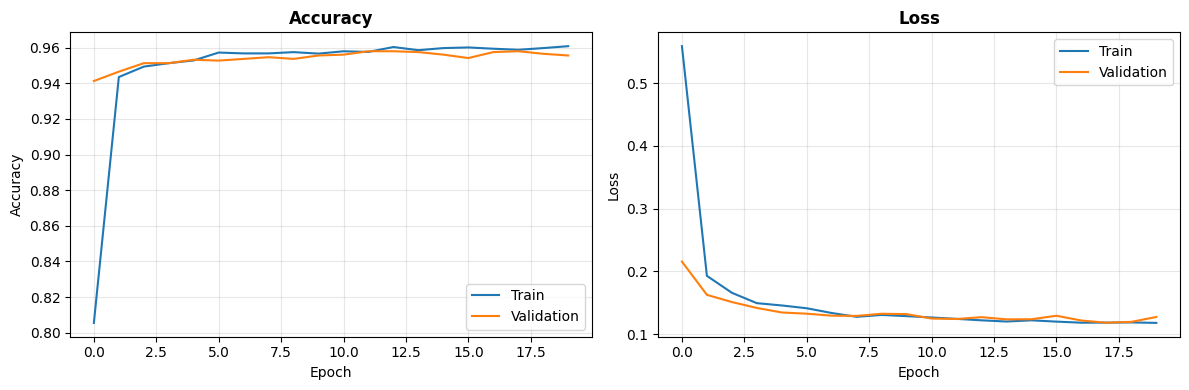

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 11. Evaluate on the test set

The test set was never used during training, so this is the real accuracy estimate.

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f'Test accuracy: {test_acc * 100:.1f}%')
print(f'Test loss:     {test_loss:.4f}')
print()

# Per-class prediction
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

print('Per-gesture accuracy:')
gesture_labels = [GESTURE_NAMES[gid] for gid in GESTURE_IDS]
for i, name in enumerate(gesture_labels):
    mask = (y_test == i)
    if mask.sum() == 0:
        continue
    acc = (y_pred[mask] == i).mean() * 100
    print(f'  {name}: {acc:.1f}%  ({mask.sum()} test windows)')

Test accuracy: 95.7%
Test loss:     0.0982

Per-gesture accuracy:
  Rest: 94.9%  (622 test windows)
  Fist: 95.8%  (600 test windows)
  Wrist extension: 96.5%  (625 test windows)


If two gestures are often confused with each other, that indicates that
those two gestures look similar in the 2-channel EMG signal.
Possible fixes: different channel selection, larger window, more data or different gesture selections.

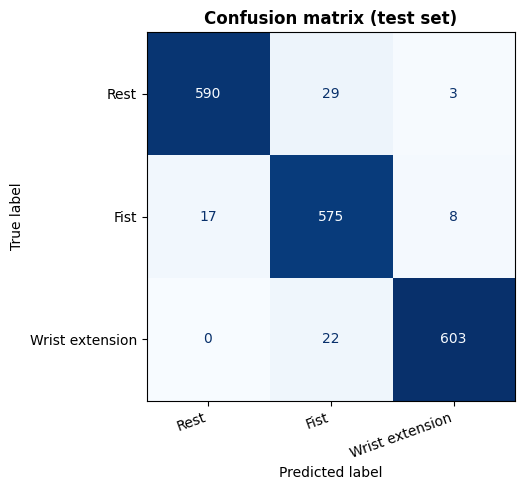

In [13]:
# Confusion matrix — rows = true gesture, columns = what the model predicted
# A perfect model would have values only on the diagonal
gesture_labels = [GESTURE_NAMES[gid] for gid in GESTURE_IDS]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gesture_labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion matrix (test set)', fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()



---
## 12. Save

Save the trained model to disk so you can load it later without retraining.

In [14]:
model.save('emg_gesture_model.keras')
print('Model saved to emg_gesture_model.keras')


Model saved to emg_gesture_model.keras


## 13. Quantize the model
I quantize the model to 8-bit integers using TensorFlow Lite

In [15]:
import tensorflow as tf

# Convert to TFLite with INT8 quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset tells the converter the real input range
def representative_dataset():
    for i in range(min(500, len(X_test))):
        sample = X_test[i:i+1].astype('float32')
        yield [sample]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

# Save it
with open('emg_gesture_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f'Model size: {len(tflite_model) / 1024:.1f} KB')

INFO:tensorflow:Assets written to: C:\Users\amirf\AppData\Local\Temp\tmpteki785x\assets


INFO:tensorflow:Assets written to: C:\Users\amirf\AppData\Local\Temp\tmpteki785x\assets


Saved artifact at 'C:\Users\amirf\AppData\Local\Temp\tmpteki785x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1506455620304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1506455621648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1506455622992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1506455621072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1506455622416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1506455623760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1506455623568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1506455622800: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\amirf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model size: 13.5 KB


## Test the TFLite model 
I compare TFLite model predictions to the original Keras model on the test set for calculating the accuracy drop

Predicted class: 2 — Expected: 2
Quantized model accuracy on test set: 95.56%
Original model accuracy was: 95.72%
Accuracy drop from quantization: 0.16%

Per-class accuracy:
  Rest: 97.11%
  Fist: 93.33%
  Wrist extension: 96.16%



C:\Users\amirf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


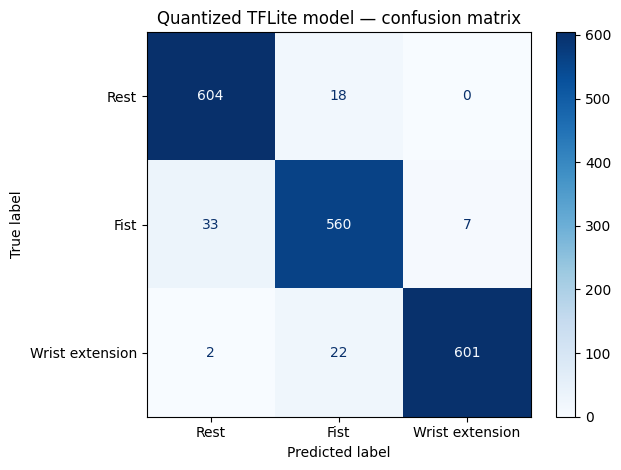

Original size (approx): 22.4 KB
Quantized size: 13.5 KB
Compression ratio: 1.67x


In [16]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Run one test window through
scale, zero_point = input_details[0]['quantization']
sample = X_test[0:1]
sample_int8 = (sample / scale + zero_point).astype(np.int8)

interpreter.set_tensor(input_details[0]['index'], sample_int8)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])
print('Predicted class:', np.argmax(output), '— Expected:', y_test[0])

# Full test set evaluation on the quantized model
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred = []
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_dtype = input_details[0]['dtype']
scale, zero_point = input_details[0]['quantization']

for i in range(len(X_test)):
    sample = X_test[i:i+1].astype('float32')
    
    if input_dtype == np.int8:
        sample = (sample / scale + zero_point).clip(-128, 127).astype(np.int8)
    
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    
    out = output[0]
    if output_details[0]['dtype'] == np.int8:
        out_scale, out_zp = output_details[0]['quantization']
        out = (out.astype('float32') - out_zp) * out_scale
    
    y_pred.append(np.argmax(out))

y_pred = np.array(y_pred)
# Accuracy
acc = np.mean(y_pred == y_test)
print(f'Quantized model accuracy on test set: {acc*100:.2f}%')
print(f'Original model accuracy was: {test_acc*100:.2f}%')
print(f'Accuracy drop from quantization: {(test_acc - acc)*100:.2f}%')
print()

# Per-class accuracy
print('Per-class accuracy:')
for i, gid in enumerate(GESTURE_IDS):
    mask = y_test == i
    class_acc = np.mean(y_pred[mask] == y_test[mask])
    print(f'  {GESTURE_NAMES[gid]}: {class_acc*100:.2f}%')
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[GESTURE_NAMES[g] for g in GESTURE_IDS])
disp.plot(cmap='Blues')
plt.title('Quantized TFLite model — confusion matrix')
plt.tight_layout()
plt.show()

# Model size comparison
original_size = len(model.weights[0].numpy().tobytes()) + sum(len(w.numpy().tobytes()) for w in model.weights)
quantized_size = len(tflite_model)
print(f'Original size (approx): {original_size / 1024:.1f} KB')
print(f'Quantized size: {quantized_size / 1024:.1f} KB')
print(f'Compression ratio: {original_size / quantized_size:.2f}x')